In [ ]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow

In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


# 📊 Dataset CIFAR-100

O **CIFAR-100** é um conjunto de dados amplamente utilizado em tarefas de **visão computacional**, especialmente para classificação de imagens. Ele foi desenvolvido como uma evolução do CIFAR-10, oferecendo um desafio mais complexo devido ao maior número de classes.

---

## 🧠 Visão Geral

* **Total de imagens:** 60.000
* **Tamanho das imagens:** 32x32 pixels
* **Canais de cor:** RGB (3 canais)
* **Divisão do dataset:**

  * 50.000 imagens para treino
  * 10.000 imagens para teste

Imagens por classe:

*  600 por classe
* 500 treino
* 100 teste
---

## 🗂️ Estrutura das Classes

O CIFAR-100 contém **100 classes diferentes**, com **600 imagens por classe**.

Essas classes são organizadas em dois níveis:

### 🔹 1. Classes Finas (*Fine Labels*)

* São as 100 categorias específicas.
* Exemplos:

  * "apple"
  * "bicycle"
  * "lion"
  * "keyboard"

### 🔹 2. Classes mãe (*Coarse Labels*)

* São 20 superclasses que agrupam as classes finas.
* Exemplos:

  * "vehicles"
  * "animals"
  * "household objects"

Cada superclasse contém 5 classes finas relacionadas.

---

## 🎯 Objetivo

O principal objetivo ao utilizar o CIFAR-100 é treinar modelos capazes de:

* Classificar imagens em **100 categorias distintas**
* Generalizar padrões visuais mesmo com imagens pequenas (32x32)
* Lidar com maior complexidade em comparação ao CIFAR-10

---

## ⚠️ Desafios

* **Baixa resolução:** dificulta a identificação de detalhes
* **Grande número de classes:** aumenta a complexidade do problema
* **Classes semelhantes:** algumas categorias são visualmente parecidas

---

## 🚀 Aplicações

O CIFAR-100 é frequentemente usado para:

* Benchmark de modelos de deep learning
* Testes com redes neurais convolucionais (CNNs)
* Pesquisa em aprendizado profundo
* Avaliação de técnicas de regularização e data augmentation

---

## 🧪 Considerações Práticas

* Normalmente é necessário aplicar **pré-processamento**, como:

  * Normalização de pixels
  * Data augmentation (rotação, flip, etc.)
* Modelos mais profundos tendem a ter melhor desempenho devido à complexidade do dataset

---

## 📌 Conclusão

O CIFAR-100 é um dataset essencial para quem deseja evoluir em visão computacional. Ele oferece um equilíbrio entre simplicidade (tamanho das imagens) e complexidade (número de classes), sendo ideal para testar arquiteturas modernas de redes neurais.

---


# Dando nome as classes:

In [ ]:
# Lista oficial das 100 classes do CIFAR-100
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 🛠️ 1. Preparação e Transformação dos Dados (ETL)

Nesta etapa, preparamos o dataset **CIFAR-100**. Como as imagens são pequenas ($32 \times 32$ pixels), precisamos de estratégias inteligentes para o modelo não sofrer de *overfitting* (decorar os dados).

### O que estamos fazendo:
1. **Data Augmentation (Aumento de Dados):** Aplicamos transformações aleatórias apenas no set de **treino**. Isso cria variações das imagens originais, ensinando o modelo a reconhecer o objeto mesmo que ele esteja levemente inclinado ou invertido.
   * `RandomHorizontalFlip`: Espelha a imagem horizontalmente.
   * `RandomRotation(15)`: Gira a imagem em até 15 graus.
2. **Normalização:** Ajustamos os valores dos pixels para que tenham média e desvio padrão específicos. Isso centraliza os dados, o que é fundamental para a estabilidade matemática das redes neurais.
   * A fórmula utilizada é: $$input = \frac{imagem - \mu}{\sigma}$$
3. **DataLoaders:** Organizamos as imagens em "lotes" (**batches**) de 64. Isso permite que a GPU processe várias imagens em paralelo, acelerando drasticamente o treino.

In [ ]:
# Transformações para o treino (com aumento de dados)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Transformações para o teste (apenas normalização)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Download e carregamento
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:05<00:00, 31.1MB/s]


# 🖼️ 2. Exploração Visual do Dataset



### Detalhes Técnicos da Visualização:
* **Desnormalização:** Como normalizamos os dados para o modelo, as cores ficam "estranhas" para o olho humano. A função reverte esse processo: $$pixel_{original} = (pixel_{norm} \times \sigma) + \mu$$
* **Transposição de Eixos:** O PyTorch lê imagens como `(Canais, Altura, Largura)`, mas bibliotecas de exibição como o `Matplotlib` esperam `(Altura, Largura, Canais)`. Usamos o `.transpose((1, 2, 0))` para corrigir isso.
* **Interface Didática:** Criamos uma grade (grid) onde cada título corresponde à classe real da imagem, facilitando a conferência visual.

Visualizando uma amostra maior do dataset...


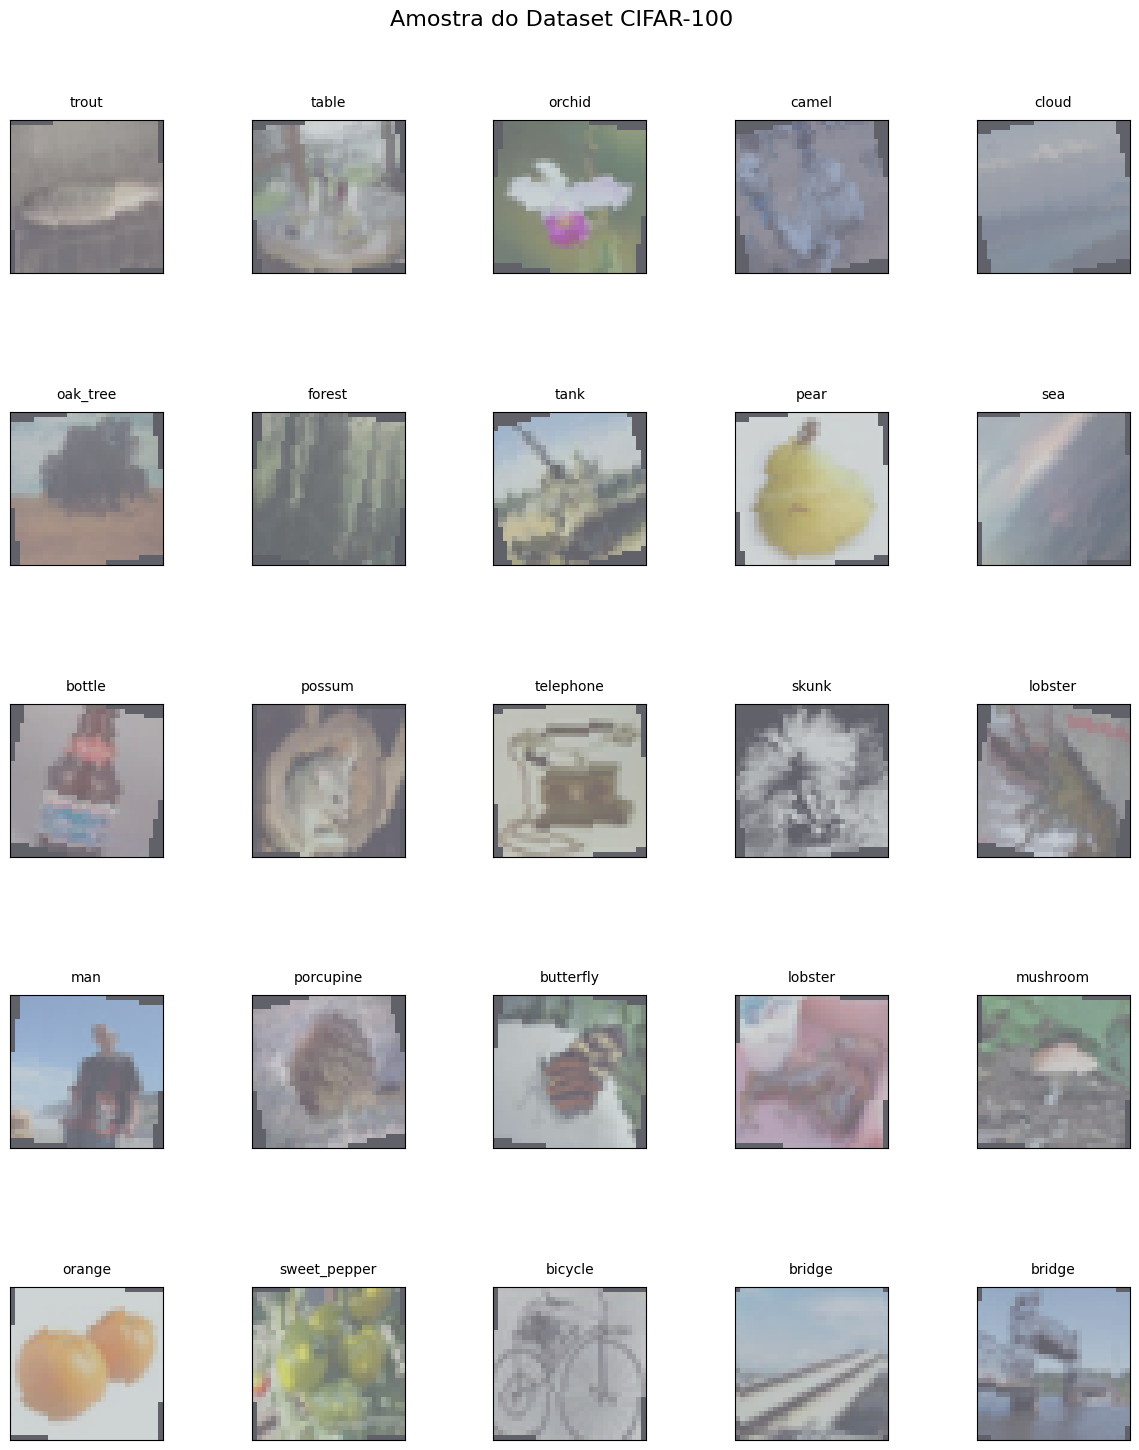

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch

# --- Bloco Didático: Visualização de Dados ---
# Objetivo: Criar uma grade visual para inspecionar as imagens e rótulos do CIFAR-100.

def visualizar_dados_cifar100(dataloader, classes, imagens_por_linha=5, total_imagens=25):
    """
    Exibe uma grade de imagens com seus rótulos abaixo,
    estilizado para análise didática no Colab.
    """
    # Pegar um lote de imagens (estamos assumindo que o batch_size é >= total_imagens)
    dataiter = iter(dataloader)
    imagens, rotulos = next(dataiter)

    # Preparar a figura
    num_linhas = int(np.ceil(total_imagens / imagens_por_linha))
    fig, axes = plt.subplots(num_linhas, imagens_por_linha, figsize=(imagens_por_linha * 2.5, num_linhas * 3))

    # Ajustar espaçamento para que o texto não sobreponha
    fig.tight_layout(pad=3.0)

    # Iterar pelas subplots e preencher com imagens e nomes
    for i, ax in enumerate(axes.flat):
        if i < total_imagens:
            # 1. Desnormalizar a imagem (converter de [-1, 1] de volta para [0, 1])
            # Nota: Isso assume a normalização padrão do ImageNet usada na ResNet.
            img = imagens[i] / 2 + 0.5     # Reverte a média
            img = img * 0.229 + 0.485      # Reverte o desvio padrão (ajuste conforme necessário se usou outra normalização)

            # 2. Converter de Tensor (C, H, W) para Numpy (H, W, C) para o matplotlib
            img_numpy = img.numpy().transpose((1, 2, 0))

            # Clipping para garantir que os valores fiquem no intervalo [0, 1]
            # e evitar o aviso do matplotlib
            img_numpy = np.clip(img_numpy, 0, 1)

            # 3. Plotar a imagem
            ax.imshow(img_numpy)

            # 4. Adicionar o nome da classe embaixo
            nome_classe = classes[rotulos[i]]
            ax.set_title(nome_classe, fontsize=10, pad=10)

            # Remover os eixos (ticks de x e y) para limpar o visual
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            # Ocultar subplots vazias se o total não for múltiplo
            ax.axis('off')

    plt.suptitle("Amostra do Dataset CIFAR-100", fontsize=16, y=1.02)
    plt.show()


print("Visualizando uma amostra maior do dataset...")
visualizar_dados_cifar100(trainloader, CIFAR100_CLASSES, imagens_por_linha=5, total_imagens=25)

# 🧠 3. Arquitetura do Modelo: Transfer Learning com ResNet-50

 Utilizamos a técnica de **Transfer Learning** (Aprendizado por Transferência).

### Por que a ResNet-50?
A **ResNet** (Residual Network) resolve o problema de redes muito profundas usando "atalhos" (skip connections), que permitem que o gradiente flua melhor durante o treino.



### Ajustes feitos:
1.  **Pesos Pré-treinados:** Usamos `weights='IMAGENET1K_V1'`, o que significa que o modelo já sabe identificar formas, texturas e objetos complexos de uma base de dados com 1,2 milhão de imagens.
2.  **Ajuste da Camada Final:** A ResNet original foi feita para 1000 classes. Como o **CIFAR-100** possui apenas 100, substituímos a última camada linear (`fc`) para projetar os recursos para apenas 100 saídas.


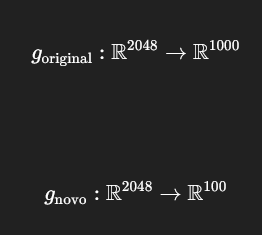

In [ ]:
def get_model():
    # Carregamos a ResNet-50 com pesos pré-treinados
    model = torchvision.models.resnet50(weights='IMAGENET1K_V1')

    # Ajuste didático: O CIFAR tem 100 classes, mas a ResNet original tem 1000.
    # Vamos trocar a última camada linear (fc) para o nosso objetivo.
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 100)

    return model.to(device)

model = get_model()

# ⚖️ 4. Função de Perda, Otimizador e Scheduler

Aqui configuramos o "cérebro" que dirá ao modelo o quanto ele errou e como ele deve se ajustar.

### 1. Função de Perda (Loss Function)
Usamos a **Cross Entropy Loss** (Entropia Cruzada), padrão para classificação multiclasse. Ela mede a distância entre a previsão do modelo e a categoria real.
$$Loss = -\sum_{c=1}^{100} y_{o,c} \log(p_{o,c})$$

### 2. Otimizador (SGD com Momentum)
O **Stochastic Gradient Descent (SGD)** com momentum funciona como uma bola descendo uma montanha: ele ganha velocidade em direções constantes, ajudando a escapar de mínimos locais.
* **Learning Rate (0.001):** Usamos uma taxa baixa para não "destruir" o conhecimento que o modelo já trouxe do ImageNet.

### 3. Scheduler (O "Ajustador")
O `ReduceLROnPlateau` é um vigia: se a perda parar de cair por 5 épocas (`patience=5`), ele reduz a taxa de aprendizado. Isso ajuda o modelo a refinar os ajustes finos no final do treino.

In [ ]:
criterion = nn.CrossEntropyLoss()
# Usamos uma taxa de aprendizado (LR) baixa para não "destruir" o conhecimento prévio da ResNet
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

# O Scheduler reduz a LR por um fator de 0.1 se a acurácia não subir em 5 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# 🚀 5. Ciclo de Treinamento e Validação

Esta é a fase onde o modelo "estuda". O processo é dividido em dois estados fundamentais:

### O Fluxo de Treino (`model.train()`):
Para cada lote de imagens, o modelo realiza quatro passos:
1.  **Forward:** Passa a imagem pela rede e gera uma previsão.
2.  **Loss:** Calcula o tamanho do erro cometido.
3.  **Backward:** Calcula o gradiente (a direção do erro) usando *backpropagation*.
4.  **Step:** O otimizador atualiza os pesos dos neurônios.

### O Fluxo de Avaliação (`model.eval()`):
Ao final de cada época, testamos o modelo em dados que ele **nunca viu** (testset). Usamos `torch.no_grad()` para desativar o cálculo de gradientes, o que economiza memória e acelera a validação.

> **Nota Didática:** Monitoramos a acurácia no set de teste para garantir que o modelo está aprendendo a generalizar, e não apenas decorando as fotos de treino.

In [ ]:
def train_model(epochs):
    train_losses, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zera os gradientes
            optimizer.zero_grad()

            # Forward + Backward + Optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Avaliação rápida no set de teste para monitorar
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        train_losses.append(running_loss / len(trainloader))
        test_accs.append(accuracy)

        print(f'Época [{epoch+1}/{epochs}] | Loss: {running_loss/len(trainloader):.3f} | Acc: {accuracy:.2f}%')
        scheduler.step(running_loss)

    return train_losses, test_accs

# Vamos rodar por 20 épocas para ver o poder do modelo
losses, accs = train_model(20)

Época [1/20] | Loss: 3.129 | Acc: 43.22%
Época [2/20] | Loss: 2.057 | Acc: 51.18%
Época [3/20] | Loss: 1.728 | Acc: 54.19%
Época [4/20] | Loss: 1.524 | Acc: 57.25%
Época [5/20] | Loss: 1.374 | Acc: 58.34%
Época [6/20] | Loss: 1.250 | Acc: 59.78%
Época [7/20] | Loss: 1.137 | Acc: 60.40%
Época [8/20] | Loss: 1.035 | Acc: 60.96%
Época [9/20] | Loss: 0.951 | Acc: 61.04%
Época [10/20] | Loss: 0.870 | Acc: 61.32%
Época [11/20] | Loss: 0.806 | Acc: 61.42%
Época [12/20] | Loss: 0.742 | Acc: 62.09%
Época [13/20] | Loss: 0.675 | Acc: 61.59%
Época [14/20] | Loss: 0.623 | Acc: 62.23%
Época [15/20] | Loss: 0.581 | Acc: 62.25%
Época [16/20] | Loss: 0.535 | Acc: 62.57%
Época [17/20] | Loss: 0.496 | Acc: 62.16%
Época [18/20] | Loss: 0.456 | Acc: 62.30%
Época [19/20] | Loss: 0.424 | Acc: 61.48%
Época [20/20] | Loss: 0.394 | Acc: 61.77%


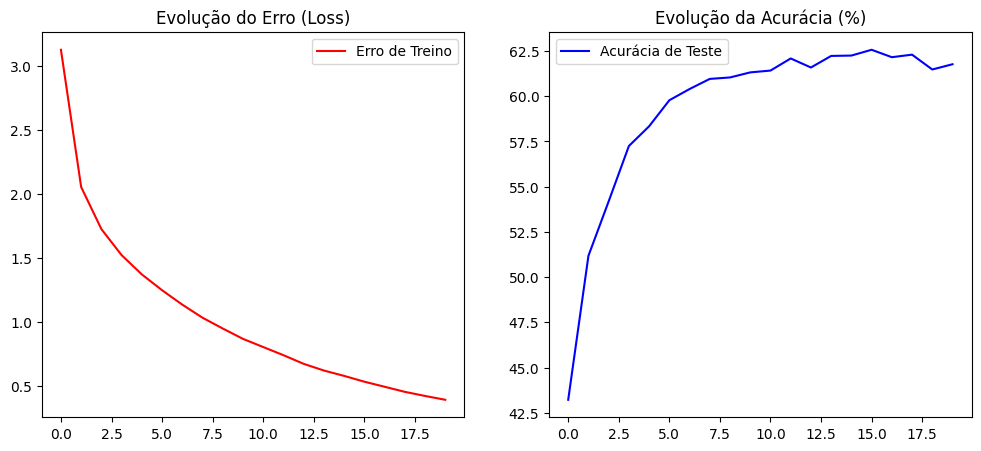

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, label='Erro de Treino', color='red')
plt.title('Evolução do Erro (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accs, label='Acurácia de Teste', color='blue')
plt.title('Evolução da Acurácia (%)')
plt.legend()
plt.show()

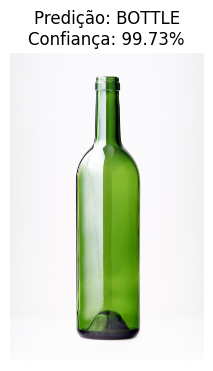

In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho
caminho_imagem = "/content/imagem1.jpg"

# 2. Carregar e tratar a imagem
img_original = Image.open(caminho_imagem).convert('RGB')

# O modelo só entende imagens 32x32 (padrão CIFAR)
transform_teste = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

img_tensor = transform_teste(img_original).unsqueeze(0).to(device)

# 3. Predição
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probabilidades = F.softmax(output, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

nome_classe = CIFAR100_CLASSES[predito.item()]

# 4. Resultado Visual
plt.figure(figsize=(4, 4))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {confianca.item()*100:.2f}%")
plt.axis('off')
plt.show()

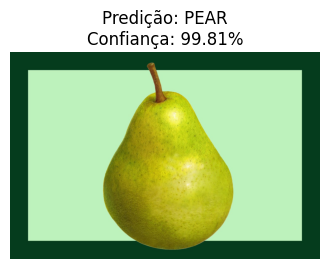

In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho
caminho_imagem = "/content/imagem2.jpg"

# 2. Carregar e tratar a imagem
img_original = Image.open(caminho_imagem).convert('RGB')

# O modelo só entende imagens 32x32 (padrão CIFAR)
transform_teste = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

img_tensor = transform_teste(img_original).unsqueeze(0).to(device)

# 3. Predição
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probabilidades = F.softmax(output, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

nome_classe = CIFAR100_CLASSES[predito.item()]

# 4. Resultado Visual
plt.figure(figsize=(4, 4))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {confianca.item()*100:.2f}%")
plt.axis('off')
plt.show()

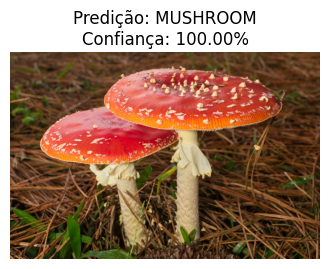

In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho
caminho_imagem = "/content/imagem3.jpg"

# 2. Carregar e tratar a imagem
img_original = Image.open(caminho_imagem).convert('RGB')

# O modelo só entende imagens 32x32 (padrão CIFAR)
transform_teste = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

img_tensor = transform_teste(img_original).unsqueeze(0).to(device)

# 3. Predição
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probabilidades = F.softmax(output, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

nome_classe = CIFAR100_CLASSES[predito.item()]

# 4. Resultado Visual
plt.figure(figsize=(4, 4))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {confianca.item()*100:.2f}%")
plt.axis('off')
plt.show()

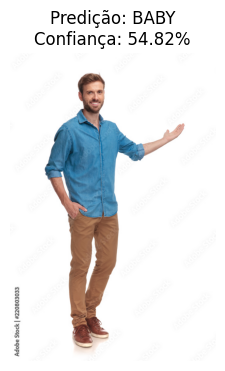

In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho
caminho_imagem = "/content/imagem4.jpg"

# 2. Carregar e tratar a imagem
img_original = Image.open(caminho_imagem).convert('RGB')

# O modelo só entende imagens 32x32 (padrão CIFAR)
transform_teste = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

img_tensor = transform_teste(img_original).unsqueeze(0).to(device)

# 3. Predição
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probabilidades = F.softmax(output, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

nome_classe = CIFAR100_CLASSES[predito.item()]

# 4. Resultado Visual
plt.figure(figsize=(4, 4))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {confianca.item()*100:.2f}%")
plt.axis('off')
plt.show()